import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

In [55]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import datetime

In [56]:
df = pd.read_csv("../Datasets/Space_Corrected.csv")

In [57]:
df

,Unnamed: 0.1,Unnamed: 0,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


# Data Preparation

df = df.drop('Unnamed: 0.1',axis=1)
df = df.drop('Unnamed: 0',axis=1)

In [58]:
df

,Unnamed: 0.1,Unnamed: 0,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


In [59]:
df = df.rename(columns={'Unnamed: 0':'Number'})

In [60]:
df = df.rename(columns={' Rocket':'Rocket'})

In [61]:
df

,Unnamed: 0.1,Number,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


In [62]:
df.isnull().sum()

Unnamed: 0.1         0
Number               0
Company Name         0
Location             0
Datum                0
Detail               0
Status Rocket        0
Rocket            3360
Status Mission       0
dtype: int64

In [63]:
df.fillna(0)

,Unnamed: 0.1,Number,Company Name,Location,Datum,Detail,Status Rocket,Rocket,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,0,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,0,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,0,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,0,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,0,Success


# Identify missing values to handle it

In [64]:
df.dtypes

Unnamed: 0.1       int64
Number             int64
Company Name      object
Location          object
Datum             object
Detail            object
Status Rocket     object
Rocket            object
Status Mission    object
dtype: object

In [65]:
df.columns

Index(['Unnamed: 0.1', 'Number', 'Company Name', 'Location', 'Datum', 'Detail',
       'Status Rocket', 'Rocket', 'Status Mission'],
      dtype='object')

In [66]:
f = df.Datum
f

0       Fri Aug 07, 2020 05:12 UTC
1       Thu Aug 06, 2020 04:01 UTC
2       Tue Aug 04, 2020 23:57 UTC
3       Thu Jul 30, 2020 21:25 UTC
4       Thu Jul 30, 2020 11:50 UTC
                   ...            
4319    Wed Feb 05, 1958 07:33 UTC
4320    Sat Feb 01, 1958 03:48 UTC
4321    Fri Dec 06, 1957 16:44 UTC
4322    Sun Nov 03, 1957 02:30 UTC
4323    Fri Oct 04, 1957 19:28 UTC
Name: Datum, Length: 4324, dtype: object

# Checking columns for changes if needed 

In [67]:
df.columns

Index(['Unnamed: 0.1', 'Number', 'Company Name', 'Location', 'Datum', 'Detail',
       'Status Rocket', 'Rocket', 'Status Mission'],
      dtype='object')

In [68]:
df. Rocket.unique()

array(['50.0 ', '29.75 ', nan, '65.0 ', '145.0 ', '64.68 ', '48.5 ',
       '90.0 ', '46.0 ', '28.3 ', '29.15 ', '7.5 ', '30.8 ', '5.3 ',
       '12.0 ', '112.5 ', '120.0 ', '153.0 ', '200.0 ', '85.0 ', '115.0 ',
       '41.8 ', '21.0 ', '31.0 ', '40.0 ', '164.0 ', '62.0 ', '37.0 ',
       '350.0 ', '39.0 ', '47.0 ', '35.0 ', '69.7 ', '109.0 ', '45.0 ',
       '123.0 ', '130.0 ', '25.0 ', '56.5 ', '15.0 ', '29.0 ', '80.0 ',
       '140.0 ', '55.0 ', '59.5 ', '450.0 ', '7.0 ', '20.14 ', '133.0 ',
       '190.0 ', '135.0 ', '20.0 ', '136.6 ', '5,000.0 ', '1,160.0 ',
       '59.0 ', '63.23 '], dtype=object)

# change the columns in their usual names

In [69]:
df = df.rename(columns={'Detail':'rocket'})

In [70]:
df = df.rename(columns={'Rocket':'price'})

In [71]:
df

,Unnamed: 0.1,Number,Company Name,Location,Datum,rocket,Status Rocket,price,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.0,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.0,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.0,Success
...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


In [72]:
df.price.unique()

array(['50.0 ', '29.75 ', nan, '65.0 ', '145.0 ', '64.68 ', '48.5 ',
       '90.0 ', '46.0 ', '28.3 ', '29.15 ', '7.5 ', '30.8 ', '5.3 ',
       '12.0 ', '112.5 ', '120.0 ', '153.0 ', '200.0 ', '85.0 ', '115.0 ',
       '41.8 ', '21.0 ', '31.0 ', '40.0 ', '164.0 ', '62.0 ', '37.0 ',
       '350.0 ', '39.0 ', '47.0 ', '35.0 ', '69.7 ', '109.0 ', '45.0 ',
       '123.0 ', '130.0 ', '25.0 ', '56.5 ', '15.0 ', '29.0 ', '80.0 ',
       '140.0 ', '55.0 ', '59.5 ', '450.0 ', '7.0 ', '20.14 ', '133.0 ',
       '190.0 ', '135.0 ', '20.0 ', '136.6 ', '5,000.0 ', '1,160.0 ',
       '59.0 ', '63.23 '], dtype=object)

In [73]:
df.price = df.price.replace('[,]','',regex=True).astype('float64')

# checking for dtype of the column

In [74]:
df.price.unique()

array([  50.  ,   29.75,     nan,   65.  ,  145.  ,   64.68,   48.5 ,
         90.  ,   46.  ,   28.3 ,   29.15,    7.5 ,   30.8 ,    5.3 ,
         12.  ,  112.5 ,  120.  ,  153.  ,  200.  ,   85.  ,  115.  ,
         41.8 ,   21.  ,   31.  ,   40.  ,  164.  ,   62.  ,   37.  ,
        350.  ,   39.  ,   47.  ,   35.  ,   69.7 ,  109.  ,   45.  ,
        123.  ,  130.  ,   25.  ,   56.5 ,   15.  ,   29.  ,   80.  ,
        140.  ,   55.  ,   59.5 ,  450.  ,    7.  ,   20.14,  133.  ,
        190.  ,  135.  ,   20.  ,  136.6 , 5000.  , 1160.  ,   59.  ,
         63.23])

In [75]:
df.price.fillna(0)

0        50.00
1        29.75
2         0.00
3        65.00
4       145.00
         ...  
4319      0.00
4320      0.00
4321      0.00
4322      0.00
4323      0.00
Name: price, Length: 4324, dtype: float64

In [76]:
df

,Unnamed: 0.1,Number,Company Name,Location,Datum,rocket,Status Rocket,price,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success
...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


In [77]:
df.price.fillna(0)

0        50.00
1        29.75
2         0.00
3        65.00
4       145.00
         ...  
4319      0.00
4320      0.00
4321      0.00
4322      0.00
4323      0.00
Name: price, Length: 4324, dtype: float64

# Exploratory Data Analytics
### What is the distribution of numerical features such as mission cost and launch year?

In [78]:
df.describe()

,Unnamed: 0.1,Number,price
count,4324.000000,4324.000000,964.000000
mean,2161.500000,2161.500000,153.792199
std,1248.375611,1248.375611,288.450732
min,0.000000,0.000000,5.300000
25%,1080.750000,1080.750000,40.000000
50%,2161.500000,2161.500000,62.000000
75%,3242.250000,3242.250000,164.000000
max,4323.000000,4323.000000,5000.000000


In [79]:

df.rocket.value_counts()



rocket
Cosmos-3MRB (65MRB) | BOR-5 Shuttle    6
Lambda-IV S | Osumi                    5
Titan IV(402)B | DSP                   5
Titan IIID | KH-11                     5
Proton K/Block D | Zond                4
                                      ..
Ariane 44P | Intelsat 709              1
Ariane 5 G | Cluster                   1
Delta II 7925 | Galaxy 9               1
Space Shuttle Endeavour | STS-77       1
Sputnik 8K71PS | Sputnik-1             1
Name: count, Length: 4278, dtype: int64

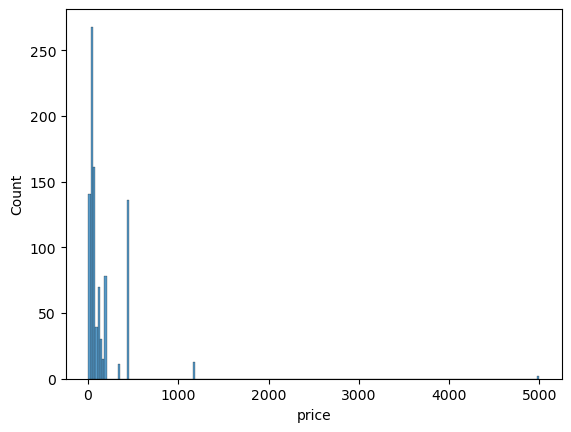

In [80]:
sb.histplot(df.price)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

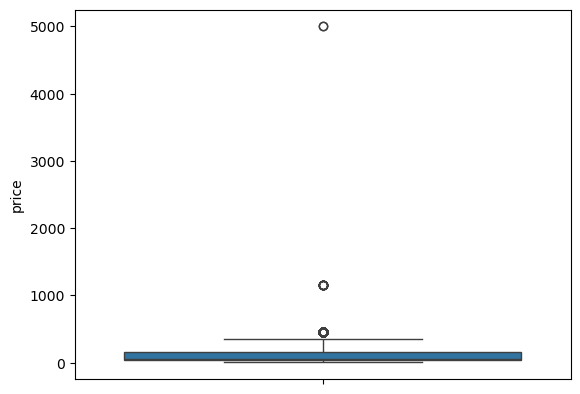

In [81]:
sb.boxplot(df.price)
plt.show

In [82]:
df['Company Name'].value_counts()



Company Name
RVSN USSR           1777
Arianespace          279
CASC                 251
General Dynamics     251
NASA                 203
VKS RF               201
US Air Force         161
ULA                  140
Boeing               136
Martin Marietta      114
SpaceX               100
MHI                   84
Northrop              83
Lockheed              79
ISRO                  76
Roscosmos             55
ILS                   46
Sea Launch            36
ISAS                  30
Kosmotras             22
US Navy               17
ISA                   13
Rocket Lab            13
Eurockot              13
ESA                   13
Blue Origin           12
IAI                   11
ExPace                10
ASI                    9
CNES                   8
AMBA                   8
MITT                   7
JAXA                   7
Land Launch            7
UT                     5
KCST                   5
CASIC                  5
Exos                   4
CECLES                 4
Arm??e de l'

In [83]:
df[df['Status Mission'] == 'Success'].groupby('Company Name').size()

Company Name
AMBA                   4
ASI                    9
Arianespace          269
Arm??e de l'Air        3
Blue Origin           12
Boeing               131
CASC                 231
CASIC                  3
CECLES                 1
CNES                   6
Douglas                1
ESA                    9
Eurockot              12
ExPace                 9
General Dynamics     203
IAI                    9
ILS                   45
IRGC                   1
ISA                    4
ISAS                  26
ISRO                  63
JAXA                   6
KARI                   1
KCST                   2
Khrunichev             1
Kosmotras             21
Land Launch            6
Lockheed              74
MHI                   80
MITT                   6
Martin Marietta      100
NASA                 186
Northrop              74
OKB-586                2
RAE                    1
RVSN USSR           1614
Rocket Lab            11
Roscosmos             51
SRC                    2
Sea Launch  

In [84]:
df[df['Status Mission'] == 'Failure'].groupby('Company Name').size().nlargest()

Company Name
RVSN USSR           121
General Dynamics     37
US Air Force         30
CASC                 14
US Navy              14
dtype: int64

In [85]:
df['Company Name'].value_counts()

Company Name
RVSN USSR           1777
Arianespace          279
CASC                 251
General Dynamics     251
NASA                 203
VKS RF               201
US Air Force         161
ULA                  140
Boeing               136
Martin Marietta      114
SpaceX               100
MHI                   84
Northrop              83
Lockheed              79
ISRO                  76
Roscosmos             55
ILS                   46
Sea Launch            36
ISAS                  30
Kosmotras             22
US Navy               17
ISA                   13
Rocket Lab            13
Eurockot              13
ESA                   13
Blue Origin           12
IAI                   11
ExPace                10
ASI                    9
CNES                   8
AMBA                   8
MITT                   7
JAXA                   7
Land Launch            7
UT                     5
KCST                   5
CASIC                  5
Exos                   4
CECLES                 4
Arm??e de l'

In [86]:
df[df['Status Mission']=='Success'].groupby('Location').size()
df

,Unnamed: 0.1,Number,Company Name,Location,Datum,rocket,Status Rocket,price,Status Mission
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success
...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success


# Launch Site Analysis
### What are the top locations used for launches?

In [87]:
aa=df['rocket'].value_counts().nlargest(10)
aa

rocket
Cosmos-3MRB (65MRB) | BOR-5 Shuttle         6
Lambda-IV S | Osumi                         5
Titan IV(402)B | DSP                        5
Titan IIID | KH-11                          5
Proton K/Block D | Zond                     4
Cosmos-3MRB (65MRB) | BOR-2 Shuttle         4
Titan IIID | KH-9                           4
Safir-1B+ | Unknown Payload                 3
Cosmos-3M (11K65M) | Strela-2M satellite    3
Cosmos-3MRB (65MRB) | BOR-4 Shuttle         3
Name: count, dtype: int64

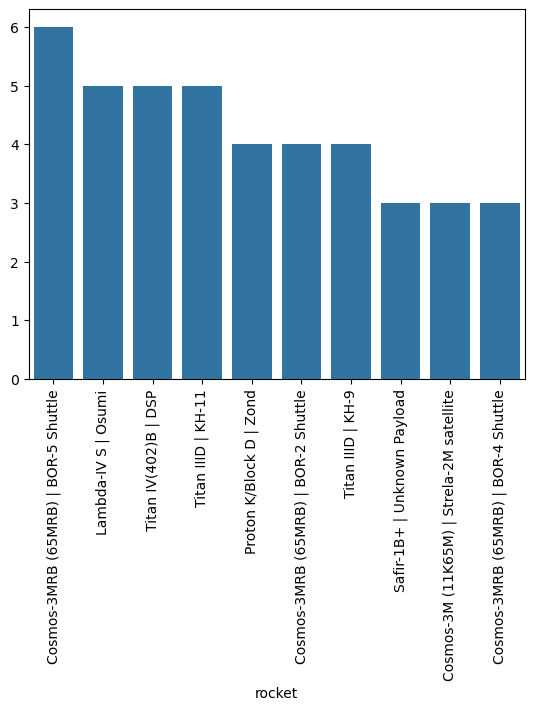

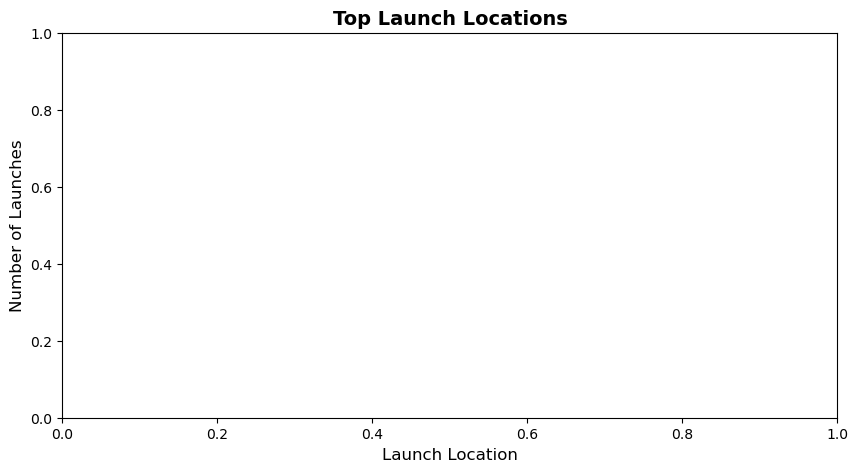

In [88]:
sb.barplot(x=aa.index,y=aa.values)
plt.xticks(rotation=90)
plt.figure(figsize=(10,5))
plt.xlabel('Launch Location', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.title('Top Launch Locations', fontsize=14, fontweight='bold')
plt.show()

### How many successful space missions has each company conducted?

In [89]:
df[['Company Name', 'price']].groupby('Company Name').mean()

,price
Company Name,
AEB,NaN
AMBA,NaN
ASI,NaN
Arianespace,170.260417
Arm??e de l'Air,NaN
Blue Origin,NaN
Boeing,177.285714
CASC,40.128228
CASIC,NaN


In [90]:
df[df['Status Mission']== 'Success']['price'].mean()

157.55114285714282

In [91]:
df[df['Status Mission']== 'Failure']['price'].mean()

67.35944444444445

### Extracting the data of month in month and year in year

In [92]:
df['month'] = df.Datum.str[4:7]
df

,Unnamed: 0.1,Number,Company Name,Location,Datum,rocket,Status Rocket,price,Status Mission,month
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,Aug
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,Aug
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,Aug
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,Jul
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success,Jul
...,...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure,Feb
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success,Feb
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure,Dec
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success,Nov


In [93]:
df['year'] = df.Datum.str[11:16]
df

,Unnamed: 0.1,Number,Company Name,Location,Datum,rocket,Status Rocket,price,Status Mission,month,year
0,0,0,SpaceX,"LC-39A, Kennedy Space Center, Florida, USA","Fri Aug 07, 2020 05:12 UTC",Falcon 9 Block 5 | Starlink V1 L9 & BlackSky,StatusActive,50.00,Success,Aug,2020
1,1,1,CASC,"Site 9401 (SLS-2), Jiuquan Satellite Launch Ce...","Thu Aug 06, 2020 04:01 UTC",Long March 2D | Gaofen-9 04 & Q-SAT,StatusActive,29.75,Success,Aug,2020
2,2,2,SpaceX,"Pad A, Boca Chica, Texas, USA","Tue Aug 04, 2020 23:57 UTC",Starship Prototype | 150 Meter Hop,StatusActive,NaN,Success,Aug,2020
3,3,3,Roscosmos,"Site 200/39, Baikonur Cosmodrome, Kazakhstan","Thu Jul 30, 2020 21:25 UTC",Proton-M/Briz-M | Ekspress-80 & Ekspress-103,StatusActive,65.00,Success,Jul,2020
4,4,4,ULA,"SLC-41, Cape Canaveral AFS, Florida, USA","Thu Jul 30, 2020 11:50 UTC",Atlas V 541 | Perseverance,StatusActive,145.00,Success,Jul,2020
...,...,...,...,...,...,...,...,...,...,...,...
4319,4319,4319,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Wed Feb 05, 1958 07:33 UTC",Vanguard | Vanguard TV3BU,StatusRetired,NaN,Failure,Feb,1958
4320,4320,4320,AMBA,"LC-26A, Cape Canaveral AFS, Florida, USA","Sat Feb 01, 1958 03:48 UTC",Juno I | Explorer 1,StatusRetired,NaN,Success,Feb,1958
4321,4321,4321,US Navy,"LC-18A, Cape Canaveral AFS, Florida, USA","Fri Dec 06, 1957 16:44 UTC",Vanguard | Vanguard TV3,StatusRetired,NaN,Failure,Dec,1957
4322,4322,4322,RVSN USSR,"Site 1/5, Baikonur Cosmodrome, Kazakhstan","Sun Nov 03, 1957 02:30 UTC",Sputnik 8K71PS | Sputnik-2,StatusRetired,NaN,Success,Nov,1957


In [94]:
df.year.astype('int64')

0       2020
1       2020
2       2020
3       2020
4       2020
        ... 
4319    1958
4320    1958
4321    1957
4322    1957
4323    1957
Name: year, Length: 4324, dtype: int64

In [95]:
df.month.dtypes

dtype('O')

In [96]:
b= df['year'].value_counts().sort_index()

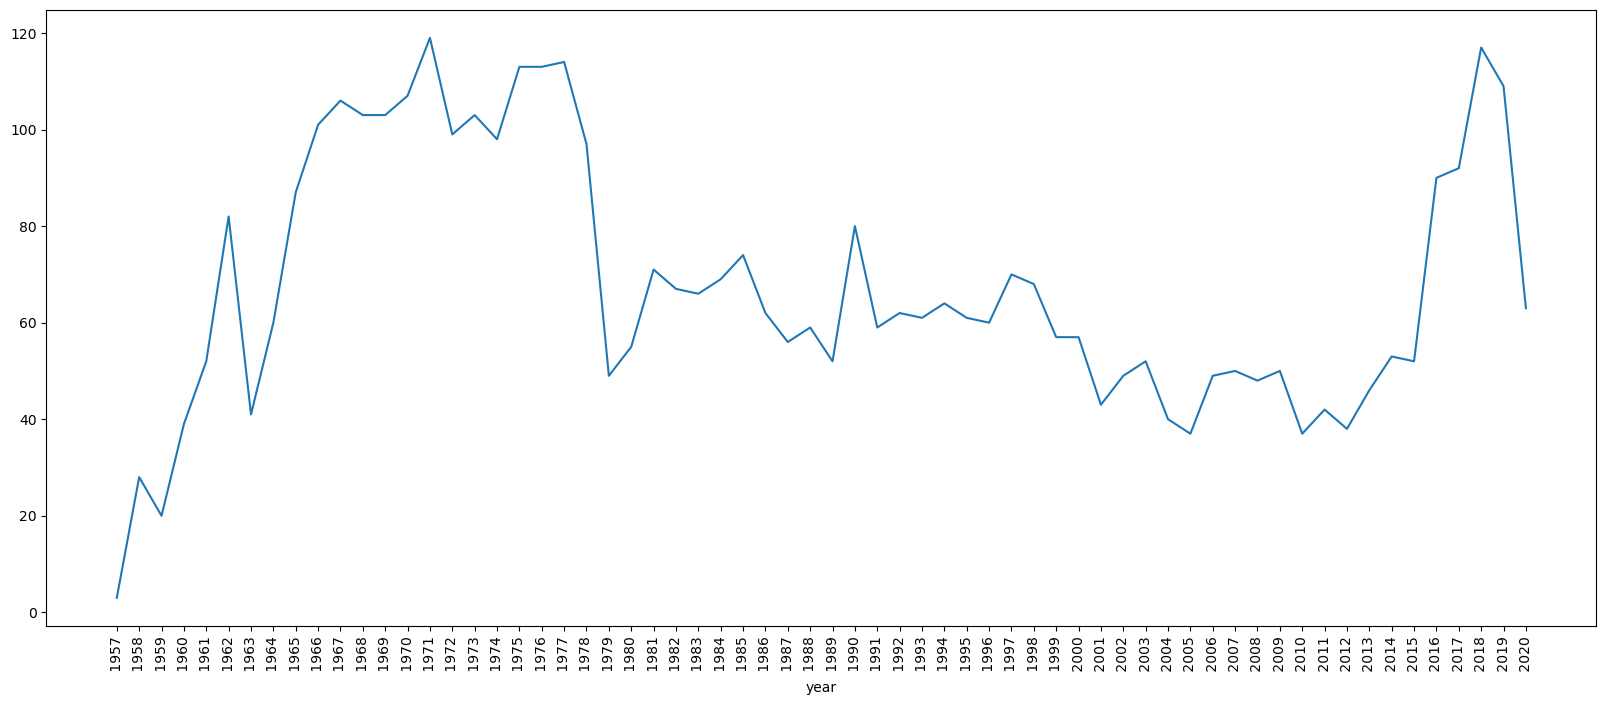

Text(0.5, 1.0, 'Top Launch Locations')

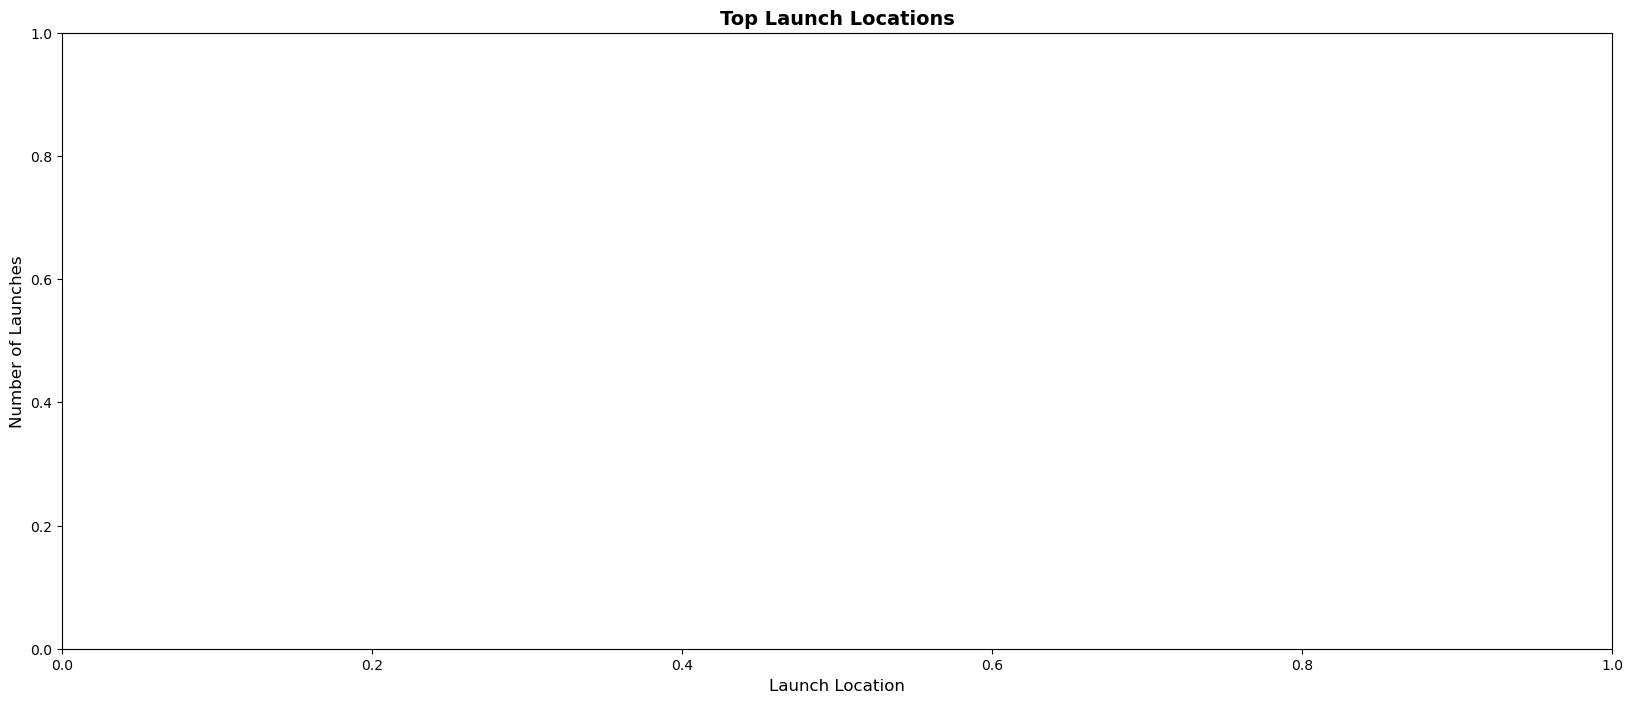

In [98]:
plt.figure(figsize=(20,8))
sb.lineplot(x=b.index,y=b.values)
plt.xticks(rotation=90)
plt.show()
plt.figure(figsize=(20,8))
plt.xlabel('Launch Location', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.title('Top Launch Locations', fontsize=14, fontweight='bold')

# Rocket ans Status Analysis

### Which rockets are used most frequently?

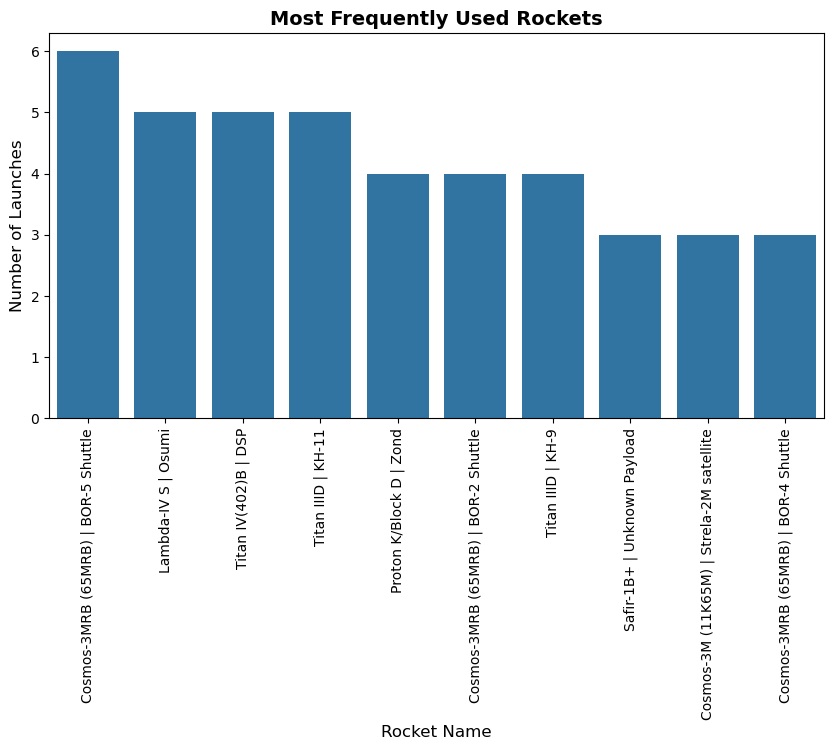

In [102]:
t=df.rocket.value_counts().nlargest(10)

plt.figure(figsize=(10,5))
sb.barplot(x=t.index, y=t.values)  
plt.xlabel('Rocket Name', fontsize=12)
plt.ylabel('Number of Launches', fontsize=12)
plt.title('Most Frequently Used Rockets', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.show()

### How many rockets are still active vs. retired?

In [103]:
df['Status Rocket'].value_counts()

Status Rocket
StatusRetired    3534
StatusActive      790
Name: count, dtype: int64

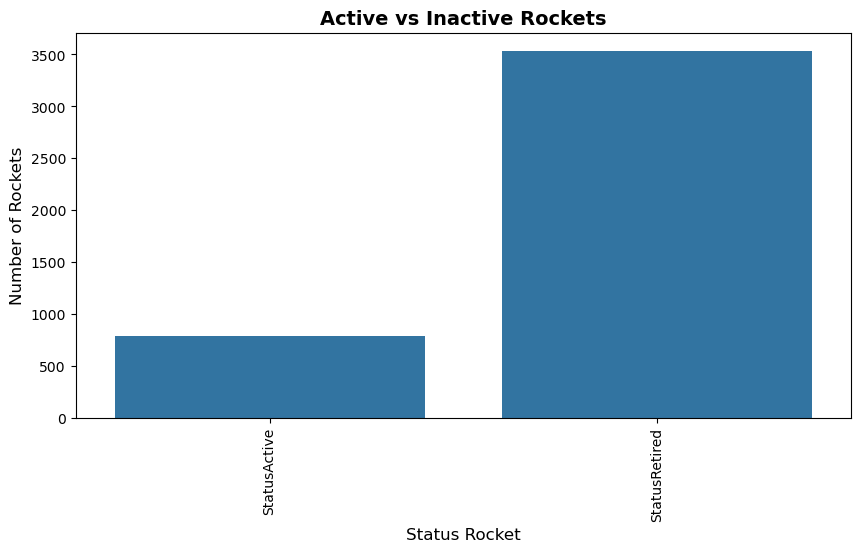

In [104]:
plt.figure(figsize=(10,5))
sb.countplot(x=df['Status Rocket']) 
plt.xlabel('Status Rocket', fontsize=12)
plt.ylabel('Number of Rockets', fontsize=12)
plt.title('Active vs Inactive Rockets', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.show()

# Cost Analysis

### Which companies spend the most?

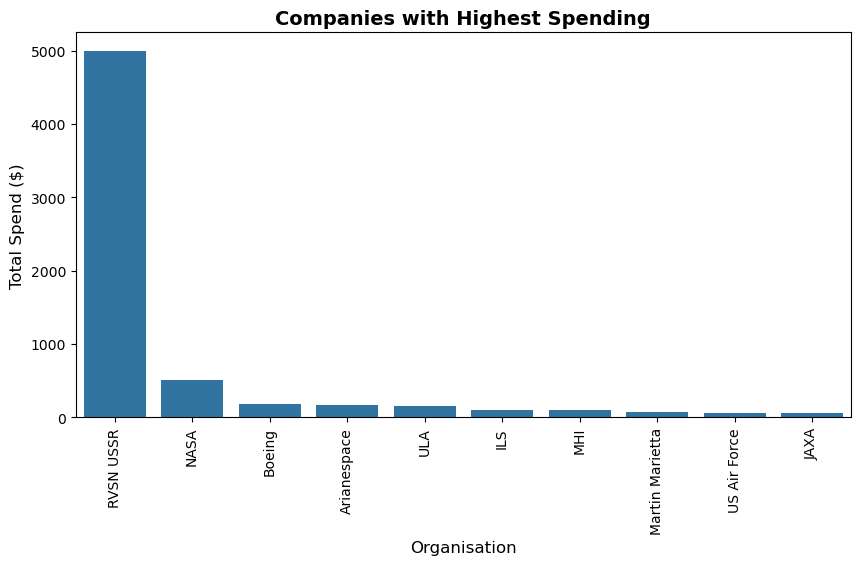

In [105]:
s= df.groupby("Company Name")["price"].mean().nlargest(10)

plt.figure(figsize=(10,5))
sb.barplot(x=s.index, y=s.values) 
plt.xlabel('Organisation', fontsize=12)
plt.ylabel('Total Spend ($)', fontsize=12)
plt.title('Companies with Highest Spending', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.show()

### Which rockets are the most expensive? 

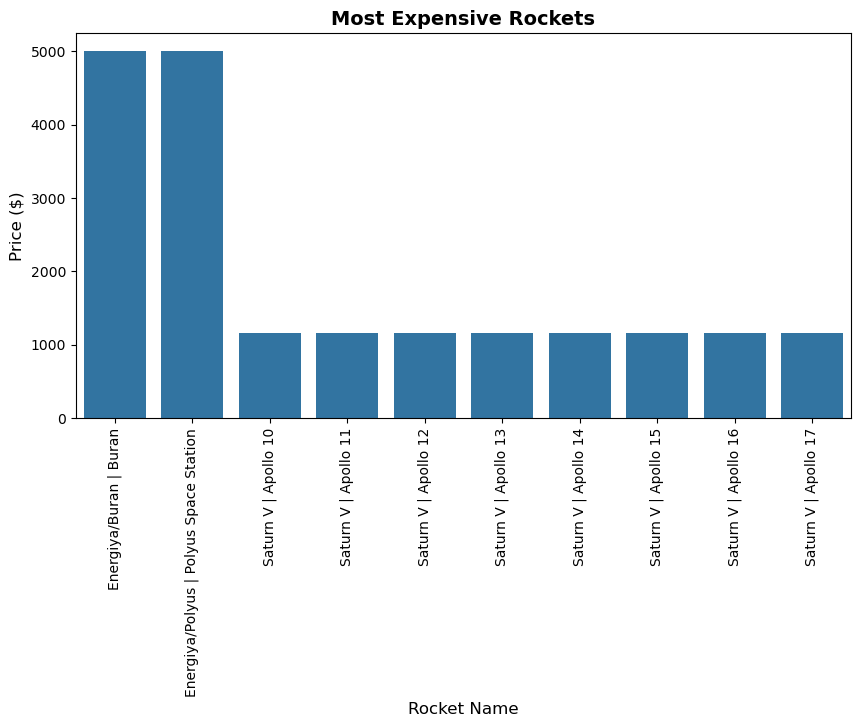

In [106]:
e= df.groupby("rocket")["price"].sum().nlargest(10)

plt.figure(figsize=(10,5))
sb.barplot(x=e.index, y=e.values)
plt.xlabel('Rocket Name', fontsize=12)
plt.ylabel('Price ($)', fontsize=12)
plt.title('Most Expensive Rockets', fontsize=14, fontweight='bold')
plt.xticks(rotation=90)
plt.show()

# Temporal Analysis

### How has the number of space launches changed over the Years?

In [108]:
df.year.unique().astype('int64')

array([2020, 2019, 2018, 2017, 2016, 2015, 2014, 2013, 2012, 2011, 2010,
       2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000, 1999,
       1998, 1997, 1996, 1995, 1994, 1993, 1992, 1991, 1990, 1989, 1988,
       1987, 1986, 1985, 1984, 1983, 1982, 1981, 1980, 1979, 1978, 1977,
       1976, 1975, 1974, 1973, 1972, 1971, 1970, 1969, 1968, 1967, 1966,
       1965, 1964, 1963, 1962, 1961, 1960, 1959, 1958, 1957], dtype=int64)

In [109]:
a2=df.groupby(['year','Status Mission']).size().reset_index()
a2

,year,Status Mission,0
0,1957,Failure,1
1,1957,Success,2
2,1958,Failure,20
3,1958,Partial Failure,2
4,1958,Success,6
...,...,...,...
173,2019,Partial Failure,2
174,2019,Prelaunch Failure,1
175,2019,Success,100
176,2020,Failure,6


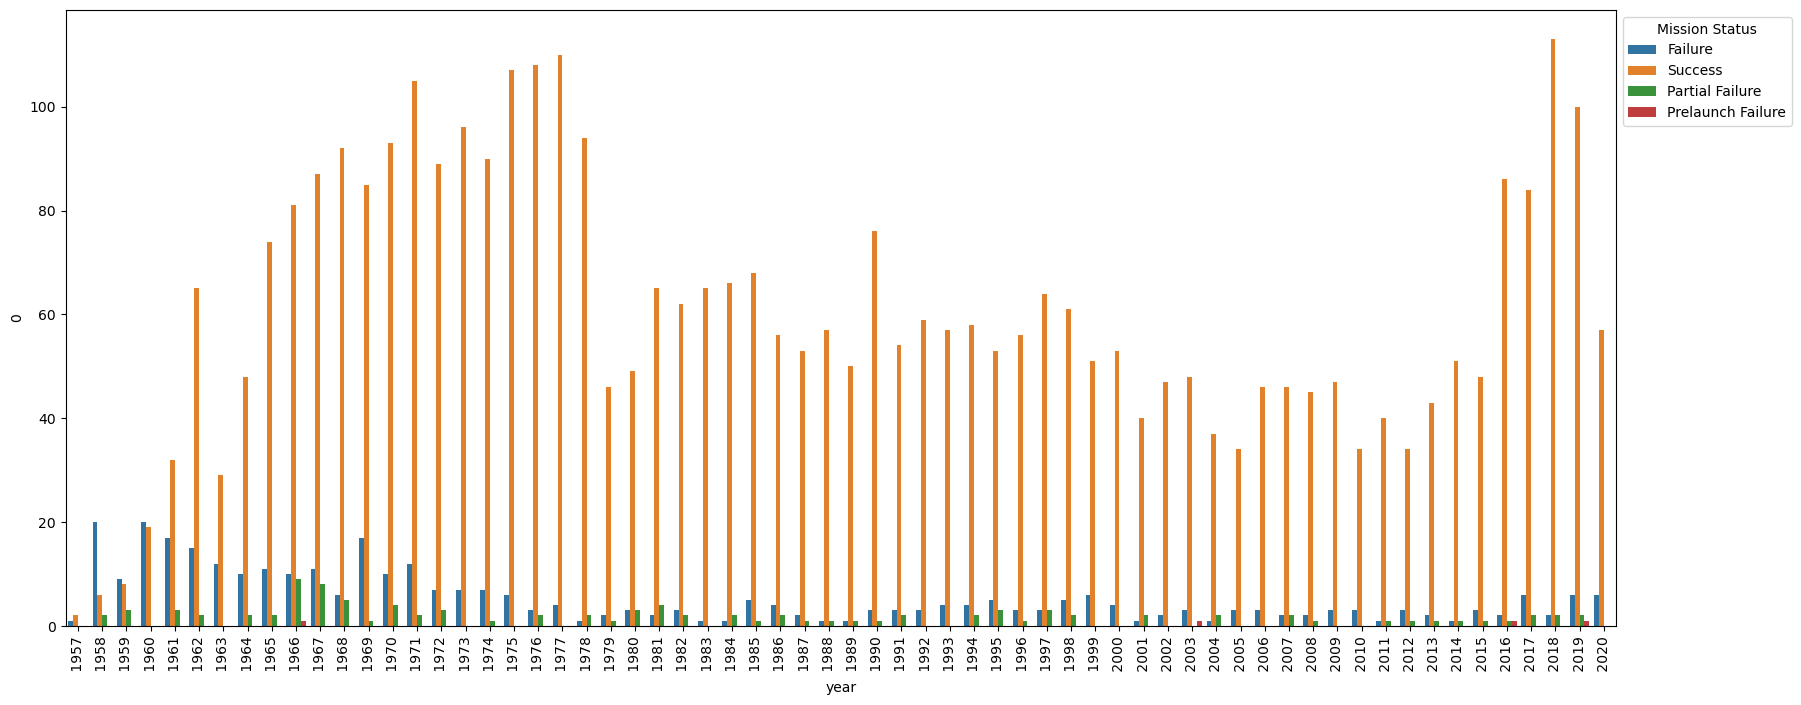

In [110]:
plt.figure(figsize=(20,8))
sb.barplot(x=a2.year,y=a2[0],hue=a2['Status Mission'])
plt.xticks(rotation=90)
plt.legend(title='Mission Status',bbox_to_anchor=(1.0,1.0))
plt.show()